In [1]:
import jax
import jax.numpy as jnp
import optax
from tqdm import tqdm
import numpy as np
import json
import time

import pennylane as qml

In [2]:
import os, sys
sys.path.append('../')

from pqcqec.utils.constants import QUBITS_FOR_GATES, QISKIT_GATES, GATE_IS_DIRECTIONAL, PENNYLANE_GATES
from pqcqec.noise.simple_noise import PennylaneNoisyGates
# from pqcqec.simulate.simulate import run_circuit_with_noise_model
from pqcqec.circuits.modify import pennylane_state_embedding

In [3]:
PQC_GATES = ['rz', 'rx', 'rz']
DATA_PATH = '../nogit/circuit_tokens/no_uncomp/5q_500g_circuit_data/'
GOOD_DATA_PATH = DATA_PATH + 'per_seed_data/'
BAD_DATA_PATH = DATA_PATH + 'poor_fidelity/'
CONFIG_PATH = DATA_PATH + 'config.json'

with open(CONFIG_PATH, 'r') as f:
    CONFIG = json.load(f)


NUM_QUBITS = CONFIG.get("qubits", 3)[0]
# NUM_GATES = CONFIG.get("gates", 4)[0] # Multiply by 2 for uncomp gates. 
NUM_GATES = 500
GATE_BLOCKS = CONFIG.get("gate_blocks", 4)
VALID_GATES = CONFIG.get("gate_dist", QISKIT_GATES)
if VALID_GATES:
    VALID_GATES = list(VALID_GATES.keys())
else:
    VALID_GATES = ['x', 'z', 'h', 'cx', 'cz']

print(f"Using {NUM_QUBITS} qubits, {NUM_GATES} gates, {GATE_BLOCKS} gate blocks, {VALID_GATES} valid gates.")

NOISE_DIST = {"x_rad": 0.01, "z_rad": 0.01, "delta_x": 0, "delta_z": 0}

PAD_ID = 0
UNDIRECTED_GATES = [gate for gate in VALID_GATES if not GATE_IS_DIRECTIONAL.get(gate, False)]
print(UNDIRECTED_GATES)

TRAIN_SZ = 0.8
VAL_SZ = 0.1
TEST_SZ = 0.1
BATCH_SIZE = 64

LEARNING_RATE = 5e-6
WEIGHT_DECAY = 1e-3

MAX_CIRCUITS = 1000


Using 5 qubits, 500 gates, 4 gate blocks, ['x', 'z', 'h', 'cx', 'cz'] valid gates.
['x', 'z', 'h', 'cz']


In [4]:

good_data = []
poor_data = []

for i, filename in enumerate(os.listdir(GOOD_DATA_PATH)):
    if i > 10000:
        break
    with open(GOOD_DATA_PATH + filename, 'r') as f:
        token_dict = json.load(f)
        good_data.append(token_dict['base_circuit_tokens'])
        f.close()

# for filename in os.listdir(BAD_DATA_PATH):
#     with open(BAD_DATA_PATH + filename, 'r') as f:
#         token_dict = json.load(f)
#         poor_data.append((token_dict['base_circuit_tokens'], token_dict['pqc_params'], token_dict['fidelity']))
#         f.close()

print(f"Number of good data samples: {len(good_data)}")
# print(f"Number of poor data samples: {len(poor_data)}")

Number of good data samples: 10001


In [5]:

def simple_circuit_simulator(circuit_ops, input_state, num_qubits, x_noise, z_noise):
    """Runs a quantum circuit with a noise model using PennyLane and PyTorch."""
    qdevice = qml.device("default.qubit", wires=num_qubits)
    input_state_time_arr = []
    circuit_loop_time_arr = []
    output_state_time_arr = []


    @qml.qnode(qdevice)
    def circuit(state):
        # pennylane_state_embedding(state, num_qubits)
        input_state_time = time.time()
        qml.StatePrep(state, wires=range(num_qubits), normalize=True, id='arbitrary_state_prep')
        input_state_time = time.time() - input_state_time
        input_state_time_arr.append(input_state_time)


        circuit_loop_time = time.time()
        for i, op in enumerate(circuit_ops):
            gate, wires, param = op
            # noise_model.apply_gate(gate, wires, angle=param)
            PENNYLANE_GATES[gate](wires=wires)
            for wire in wires:
                qml.RX(x_noise[i], wires=[wire])  # Example noise application
                qml.RZ(z_noise[i], wires=[wire])  # Example noise application

        circuit_loop_time = time.time() - circuit_loop_time
        circuit_loop_time_arr.append(circuit_loop_time)

        output_state_time = time.time()
        output = qml.state()
        output_state_time = time.time() - output_state_time
        output_state_time_arr.append(output_state_time)

        return output

    # The function now directly returns the output of the torch interface qnode
    return circuit(input_state), input_state_time_arr, circuit_loop_time_arr, output_state_time_arr


def simple_circuit_generator(circuit_ops, num_qubits, x_noise, z_noise):
    """Runs a quantum circuit with a noise model using PennyLane and PyTorch."""
    qdevice = qml.device("default.qubit", wires=num_qubits)

    @qml.qnode(qdevice)
    def circuit(state):
        # pennylane_state_embedding(state, num_qubits)
        qml.StatePrep(state, wires=range(num_qubits), normalize=True, id='arbitrary_state_prep')
        for i, op in enumerate(circuit_ops):
            gate, wires, param = op
            # noise_model.apply_gate(gate, wires, angle=param)
            PENNYLANE_GATES[gate](wires=wires)
            for wire in wires:
                qml.RX(x_noise[i], wires=[wire])  # Example noise application
                qml.RZ(z_noise[i], wires=[wire])  # Example noise application

        return qml.state()

    # The function now directly returns the interface qnode
    return circuit

In [6]:

# def torch_simple_circuit_simulator(circuit_ops, input_state, num_qubits, x_noise, z_noise):
#     """Runs a quantum circuit with a noise model using PennyLane and PyTorch."""
#     qdevice = qml.device("default.qubit", wires=num_qubits)

#     @qml.qnode(qdevice, interface='torch', diff_method='backprop')
#     def circuit(state):
#         pennylane_state_embedding(state, num_qubits)
#         for i, op in enumerate(circuit_ops):
#             gate, wires, param = op
#             # noise_model.apply_gate(gate, wires, angle=param)
#             PENNYLANE_GATES[gate](wires=wires)
#             for wire in wires:
#                 qml.RX(x_noise[i], wires=[wire])  # Example noise application
#                 qml.RZ(z_noise[i], wires=[wire])  # Example noise application

#         return qml.state()

#     # The function now directly returns the output of the torch interface qnode
#     return circuit(input_state)


# def torch_simple_circuit_generator(circuit_ops, num_qubits, x_noise, z_noise):
#     """Runs a quantum circuit with a noise model using PennyLane and PyTorch."""
#     qdevice = qml.device("default.qubit", wires=num_qubits)

#     @qml.qnode(qdevice, interface='torch', diff_method='backprop')
#     def circuit(state):
#         pennylane_state_embedding(state, num_qubits)
#         for i, op in enumerate(circuit_ops):
#             gate, wires, param = op
#             # noise_model.apply_gate(gate, wires, angle=param)
#             PENNYLANE_GATES[gate](wires=wires)
#             for wire in wires:
#                 qml.RX(x_noise[i], wires=[wire])  # Example noise application
#                 qml.RZ(z_noise[i], wires=[wire])  # Example noise application

#         return qml.state()

#     # The function now directly returns the interface qnode
#     return circuit

In [7]:
input_states = np.zeros((100, 2**NUM_QUBITS))
input_states[:,0] = 1.0
x_noise = np.ones(NUM_GATES) * 0.01
z_noise = np.ones(NUM_GATES) * 0.01


In [8]:
sim_input_time = []
sim_circuit_time = []
sim_output_time = []

for data in tqdm(good_data[:MAX_CIRCUITS]):
    output_state, input_time_val, circuit_time_val, output_time_val = simple_circuit_simulator(data, input_states, NUM_QUBITS, x_noise, z_noise)
    sim_input_time.append(input_time_val)
    sim_circuit_time.append(circuit_time_val)
    sim_output_time.append(output_time_val)

sim_input_time = np.array(sim_input_time)
sim_circuit_time = np.array(sim_circuit_time)
sim_output_time = np.array(sim_output_time)

print(sim_input_time.shape, sim_circuit_time.shape, sim_output_time.shape)



100%|██████████| 1000/1000 [01:49<00:00,  9.14it/s]

(1000, 1) (1000, 1) (1000, 1)


In [9]:
print(f"Output state: {output_state.shape}")

Output state: (100, 32)


In [10]:

start_time = time.time()
output_state, input_state_time, circuit_loop_time, output_state_time = simple_circuit_simulator(good_data[0], input_states, NUM_QUBITS, x_noise, z_noise)
end_time = time.time()

execution_time = end_time - start_time
print(f"Execution time: {execution_time} seconds")
print(f"Output state: {output_state.shape}")
print(f"Input  state time: {input_state_time} seconds")
print(f"Circuit loop time: {circuit_loop_time} seconds")
print(f"Output state time: {output_state_time} seconds")


Execution time: 0.11458015441894531 seconds
Output state: (100, 32)
Input  state time: [0.000102996826171875] seconds
Circuit loop time: [0.00617218017578125] seconds
Output state time: [8.821487426757812e-06] seconds


In [11]:

start_time = time.time()
output_state, input_state_time, circuit_loop_time, output_state_time = simple_circuit_simulator(good_data[0], input_states[0], NUM_QUBITS, x_noise, z_noise)
end_time = time.time()

execution_time = end_time - start_time
print(f"Execution time: {execution_time} seconds")
print(f"Output state: {output_state.shape}")
print(f"Input  state time: {input_state_time} seconds")
print(f"Circuit loop time: {circuit_loop_time} seconds")
print(f"Output state time: {output_state_time} seconds")


Execution time: 0.05455207824707031 seconds
Output state: (32,)
Input  state time: [0.00011992454528808594] seconds
Circuit loop time: [0.006134986877441406] seconds
Output state time: [6.9141387939453125e-06] seconds


In [12]:

start_time = time.time()
output_state, input_state_time, circuit_loop_time, output_state_time = simple_circuit_simulator(good_data[0], input_states[:50], NUM_QUBITS, x_noise, z_noise)
end_time = time.time()

execution_time = end_time - start_time
print(f"Execution time: {execution_time} seconds")
print(f"Output state: {output_state.shape}")
print(f"Input  state time: {input_state_time} seconds")
print(f"Circuit loop time: {circuit_loop_time} seconds")
print(f"Output state time: {output_state_time} seconds")


Execution time: 0.08387398719787598 seconds
Output state: (50, 32)
Input  state time: [0.00015473365783691406] seconds
Circuit loop time: [0.00596308708190918] seconds
Output state time: [5.0067901611328125e-06] seconds


In [13]:
time_list = []
for i in range(10):
    start_time = time.time()
    output_state, input_state_time, circuit_loop_time, output_state_time = simple_circuit_simulator(good_data[0], input_states[:], NUM_QUBITS, x_noise, z_noise)
    end_time = time.time()

    execution_time = end_time - start_time
    time_list.append(execution_time)
    print(f"Execution time: {execution_time} seconds")
    print(f"Output state: {output_state.shape}")
    print(f"Input  state time: {input_state_time} seconds")
    print(f"Circuit loop time: {circuit_loop_time} seconds")
    print(f"Output state time: {output_state_time} seconds")

Execution time: 0.11282992362976074 seconds
Output state: (100, 32)
Input  state time: [0.0001239776611328125] seconds
Circuit loop time: [0.006083965301513672] seconds
Output state time: [5.9604644775390625e-06] seconds
Execution time: 0.11185598373413086 seconds
Output state: (100, 32)
Input  state time: [0.00016117095947265625] seconds
Circuit loop time: [0.005734682083129883] seconds
Output state time: [5.245208740234375e-06] seconds
Execution time: 0.11143183708190918 seconds
Output state: (100, 32)
Input  state time: [8.106231689453125e-05] seconds
Circuit loop time: [0.005906820297241211] seconds
Output state time: [4.0531158447265625e-06] seconds
Execution time: 0.11184382438659668 seconds
Output state: (100, 32)
Input  state time: [6.008148193359375e-05] seconds
Circuit loop time: [0.0059528350830078125] seconds
Output state time: [4.0531158447265625e-06] seconds
Execution time: 0.11186933517456055 seconds
Output state: (100, 32)
Input  state time: [6.699562072753906e-05] seco

In [14]:
circuit_nodes = []
start_time = time.time()
for data in tqdm(good_data):
    # input_state = np.zeros((100, 2**NUM_QUBITS))
    # input_state[:,0] = 1.0
    exec_node = simple_circuit_generator(data, NUM_QUBITS, x_noise, z_noise)
    circuit_nodes.append(exec_node)
end_time = time.time()
print(f"Execution time - circuit creation: {end_time - start_time} seconds")
    # print(f"Output state: {output_state}")

100%|██████████| 10001/10001 [00:01<00:00, 8081.52it/s]

Execution time - circuit creation: 1.2392079830169678 seconds


In [15]:
print(f'Running circuit exec nodes with 1 state to set up compiled nodes...')
for exec_node in tqdm(circuit_nodes[:MAX_CIRCUITS]):
    output_state = exec_node(input_states[0])
    # print(f"Output state: {output_state.shape}")

Running circuit exec nodes with 1 state to set up compiled nodes...


100%|██████████| 1000/1000 [00:58<00:00, 17.09it/s]


In [16]:
print(f'Running circuit exec nodes with all 100 states...')

for exec_node in tqdm(circuit_nodes[:MAX_CIRCUITS]):
    output_state = exec_node(input_states)
    # print(f"Output state: {output_state.shape}")


Running circuit exec nodes with all 100 states...


100%|██████████| 1000/1000 [01:57<00:00,  8.51it/s]


In [17]:
print(f'Running circuit exec nodes again...')


for exec_node in tqdm(circuit_nodes[:MAX_CIRCUITS]):
    output_state = exec_node(input_states)
    # print(f"Output state: {output_state.shape}")



Running circuit exec nodes again...


100%|██████████| 1000/1000 [01:58<00:00,  8.44it/s]


In [18]:
start_time = time.time()
circuit_nodes[0](input_states)
end_time = time.time()

execution_time = end_time - start_time
print(f"Execution time - 100 states: {execution_time} seconds")


Execution time - 100 states: 0.1166682243347168 seconds


In [19]:

start_time = time.time()
circuit_nodes[0](input_states[0])
end_time = time.time()

execution_time = end_time - start_time
print(f"Execution time - 1 states: {execution_time} seconds")


Execution time - 1 states: 0.0602869987487793 seconds


In [20]:
# print(f'Running circuit exec nodes for just 10 states...')

# for exec_node in tqdm(circuit_nodes):
#     output_state = exec_node(input_states)
#     # print(f"Output state: {output_state.shape}")


In [21]:
start_time = time.time()
circuit_nodes[0](input_states[:10])
end_time = time.time()

execution_time = end_time - start_time
print(f"Execution time - 10 states: {execution_time} seconds")


Execution time - 10 states: 0.06894207000732422 seconds


In [22]:
import pennylane as qml
import time

# Assuming PENNYLANE_GATES is defined elsewhere
# Example:
# PENNYLANE_GATES = { 'Hadamard': qml.Hadamard, 'CNOT': qml.CNOT }

def timed_circuit_simulator(circuit_ops, input_state, num_qubits, x_noise, z_noise):
    """
    Runs a quantum circuit and returns timings for distinct phases of the simulation.
    """
    qdevice = qml.device("default.qubit", wires=num_qubits)

    # QNode 1: Measures the time for state preparation ONLY
    @qml.qnode(qdevice)
    def state_prep_circuit(state):
        qml.StatePrep(state, wires=range(num_qubits))
        return qml.state()

    # QNode 2: The full circuit including state prep and gates
    @qml.qnode(qdevice)
    def full_circuit(state, ops, x_noise_params, z_noise_params):
        qml.StatePrep(state, wires=range(num_qubits))
        for i, op in enumerate(ops):
            gate, wires, param = op
            PENNYLANE_GATES[gate](wires=wires)
            for wire in wires:
                qml.RX(x_noise_params[i], wires=[wire])
                qml.RZ(z_noise_params[i], wires=[wire])
        return qml.state()

    # --- Execute and Time Each Phase ---

    # 1. Time the state preparation step
    start_time_1 = time.time()
    state_prep_circuit(input_state)
    input_state_time = time.time() - start_time_1

    # 2. Time the full process (state prep + circuit ops)
    start_time_2 = time.time()
    output_state = full_circuit(input_state, ops=circuit_ops, x_noise_params=x_noise, z_noise_params=z_noise)
    total_time = time.time() - start_time_2
    
    # 3. Calculate the circuit time by subtraction
    # This represents the time for applying gates, noise, and finalizing the state measurement.
    circuit_execution_time = total_time - input_state_time
    
    # The time for the final qml.state() call is included in the circuit_execution_time.
    # We'll return 0 for it as it's not a separable step.
    output_state_time = 0 

    return output_state, input_state_time, circuit_execution_time, output_state_time


In [23]:
sim_input_time = []
sim_circuit_time = []
sim_output_time = [] # This will collect zeros, but maintains the structure

for data in tqdm(good_data[:MAX_CIRCUITS]):
    # Call the new function
    output_state, input_time_val, circuit_time_val, output_time_val = timed_circuit_simulator(
        data, input_states, NUM_QUBITS, x_noise, z_noise
    )
    
    sim_input_time.append(input_time_val)
    sim_circuit_time.append(circuit_time_val)
    sim_output_time.append(output_time_val)

    

100%|██████████| 1000/1000 [01:53<00:00,  8.81it/s]


--- Timing Analysis Results ---

📊 Basic Statistics (in seconds):
Metric          | Input Prep      | Circuit Exec    | Total Time     
-----------------------------------------------------------------
Mean            | 0.000321        | 0.112015        | 0.112336       
Median          | 0.000318        | 0.111406        | 0.111739       
Std Dev         | 0.000046        | 0.004383        | 0.004402       

Best Case (Min Total Time): 0.102009 s
Worst Case (Max Total Time): 0.137891 s


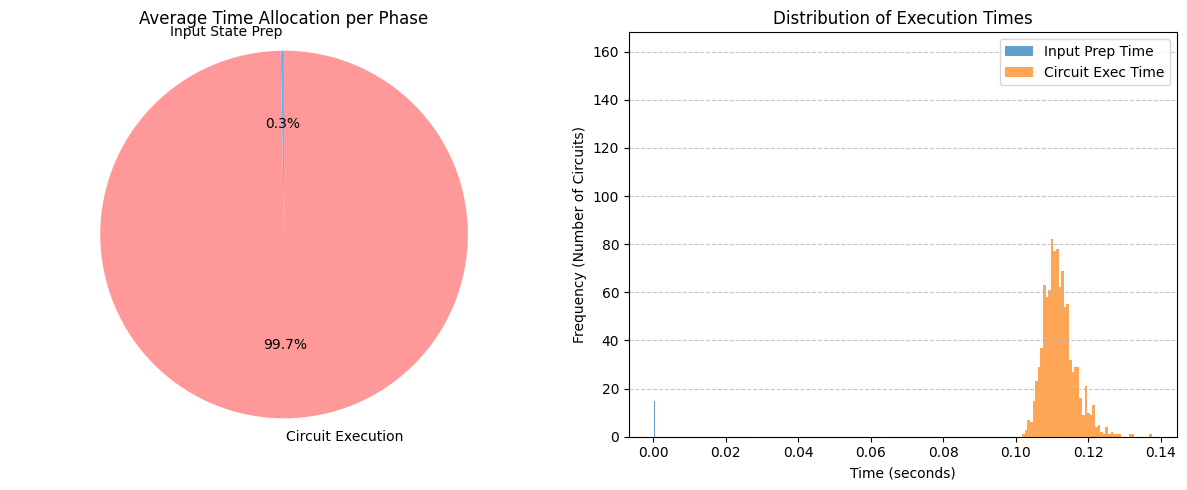

In [24]:
import numpy as np
import matplotlib.pyplot as plt

def analyze_timings(input_times, circuit_times):
    """
    Performs and prints a NumPy-based analysis of circuit timing data.

    Args:
        input_times (list or np.ndarray): A list of timings for the state preparation phase.
        circuit_times (list or np.ndarray): A list of timings for the gate execution phase.
    """
    # 1. Convert lists to NumPy arrays for efficient computation
    input_arr = np.array(input_times)
    circuit_arr = np.array(circuit_times)
    total_arr = input_arr + circuit_arr

    print("--- Timing Analysis Results ---")

    # 2. Calculate and print basic statistics for each phase
    print("\n📊 Basic Statistics (in seconds):")
    print(f"{'Metric':<15} | {'Input Prep':<15} | {'Circuit Exec':<15} | {'Total Time':<15}")
    print("-" * 65)
    
    # Mean (Average)
    mean_input = np.mean(input_arr)
    mean_circuit = np.mean(circuit_arr)
    mean_total = np.mean(total_arr)
    print(f"{'Mean':<15} | {mean_input:<15.6f} | {mean_circuit:<15.6f} | {mean_total:<15.6f}")

    # Median (50th percentile, robust to outliers)
    median_input = np.median(input_arr)
    median_circuit = np.median(circuit_arr)
    median_total = np.median(total_arr)
    print(f"{'Median':<15} | {median_input:<15.6f} | {median_circuit:<15.6f} | {median_total:<15.6f}")

    # Standard Deviation (Measure of spread/variability)
    std_input = np.std(input_arr)
    std_circuit = np.std(circuit_arr)
    std_total = np.std(total_arr)
    print(f"{'Std Dev':<15} | {std_input:<15.6f} | {std_circuit:<15.6f} | {std_total:<15.6f}")

    # Min/Max
    min_total = np.min(total_arr)
    max_total = np.max(total_arr)
    print(f"\nBest Case (Min Total Time): {min_total:.6f} s")
    print(f"Worst Case (Max Total Time): {max_total:.6f} s")


    # 3. --- Visualizations ---
    
    # Pie Chart: Percentage of time spent in each phase
    avg_times = [mean_input, mean_circuit]
    labels = ['Input State Prep', 'Circuit Execution']
    
    plt.figure(figsize=(12, 5))
    
    plt.subplot(1, 2, 1)
    plt.pie(avg_times, labels=labels, autopct='%1.1f%%', startangle=90, colors=['#66b3ff','#ff9999'])
    plt.title('Average Time Allocation per Phase')
    plt.axis('equal')  # Equal aspect ratio ensures that pie is drawn as a circle.

    # Histograms: Distribution of timings
    plt.subplot(1, 2, 2)
    # Use a sensible number of bins, or let matplotlib decide with 'auto'
    bins = min(len(input_times) // 5, 50) if len(input_times) > 20 else 10
    plt.hist(input_arr, bins=bins, alpha=0.7, label='Input Prep Time')
    plt.hist(circuit_arr, bins=bins, alpha=0.7, label='Circuit Exec Time')
    plt.xlabel("Time (seconds)")
    plt.ylabel("Frequency (Number of Circuits)")
    plt.title("Distribution of Execution Times")
    plt.legend()
    plt.grid(axis='y', linestyle='--', alpha=0.7)

    plt.tight_layout()
    plt.show()


# --- How to Use ---


# 2. Pass your collected lists to the analysis function
analyze_timings(sim_input_time, sim_circuit_time)

# Performance Profiling and Bottleneck Analysis

This section contains comprehensive timing and profiling tools to identify performance bottlenecks in quantum circuit execution.

In [25]:
import cProfile
import pstats
import io
from contextlib import contextmanager
import matplotlib.pyplot as plt
import pandas as pd
from collections import defaultdict
from typing import Optional, Generator

# Profiling context manager
@contextmanager
def profile_execution(
    description: str = "Execution Profile",
    sort_by: str = 'cumulative',
    dump_file: Optional[str] = None
) -> Generator[cProfile.Profile, None, None]:
    """
    A flexible context manager for profiling Python code execution.

    Args:
        description (str): A description for the profiled block.
        sort_by (str): The statistic to sort the profile report by.
                       Common options: 'cumulative', 'tottime', 'calls'.
        print_stats (int): The number of top functions to print to the console.
                           Set to 0 or a negative number to disable console printing.
        dump_file (Optional[str]): If provided, saves the complete profiling
                                   statistics to the specified file for later analysis.
    """
    prof = cProfile.Profile()
    start_time = time.time()
    try:
        prof.enable()
        yield prof
    finally:
        prof.disable()
        end_time = time.time()

        # --- Enhanced Output ---
        print(f"\n--- {description} ---")
        print(f"Total Wall Time: {end_time - start_time:.4f} seconds")

        s = io.StringIO()
        # pstats.Stats can take the Profile object directly
        stats = pstats.Stats(prof, stream=s).sort_stats(sort_by)

        print(f"All functions sorted by '{sort_by}':")
        stats.print_stats()
        print(s.getvalue())

        if dump_file:
            prof.dump_stats(dump_file)
            print(f"💾 Full profiling stats saved to '{dump_file}'")
        
        print("-" * (len(description) + 6))


# Custom timer class for detailed analysis
class DetailedTimer:
    def __init__(self):
        self.times = defaultdict(list)
        self.current_section = None
        self.section_start = None
    
    def start_section(self, section_name):
        if self.current_section:
            self.end_section()
        self.current_section = section_name
        self.section_start = time.time()
    
    def end_section(self):
        if self.current_section and self.section_start:
            elapsed = time.time() - self.section_start
            self.times[self.current_section].append(elapsed)
            self.current_section = None
            self.section_start = None
    
    def add_time(self, section_name, elapsed_time):
        self.times[section_name].append(elapsed_time)
    
    def get_summary(self):
        summary = {}
        for section, times in self.times.items():
            summary[section] = {
                'mean': np.mean(times),
                'std': np.std(times),
                'min': np.min(times),
                'max': np.max(times),
                'total': np.sum(times),
                'count': len(times)
            }
        return summary
    
    def plot_summary(self, figsize=(12, 8)):
        summary = self.get_summary()
        if not summary:
            print("No timing data to plot")
            return
        
        sections = list(summary.keys())
        means = [summary[s]['mean'] for s in sections]
        stds = [summary[s]['std'] for s in sections]
        
        fig, (ax1, ax2) = plt.subplots(2, 1, figsize=figsize)
        
        # Bar plot of mean times
        ax1.bar(sections, means, yerr=stds, capsize=5)
        ax1.set_ylabel('Time (seconds)')
        ax1.set_title('Mean Execution Time by Section')
        ax1.tick_params(axis='x', rotation=45)
        
        # Box plot for distribution
        times_data = [self.times[s] for s in sections]
        ax2.boxplot(times_data, labels=sections)
        ax2.set_ylabel('Time (seconds)')
        ax2.set_title('Execution Time Distribution by Section')
        ax2.tick_params(axis='x', rotation=45)
        
        plt.tight_layout()
        plt.show()
        
        # Print summary table
        df = pd.DataFrame(summary).T
        print("\nDetailed Timing Summary:")
        print(df.round(6))

In [26]:
# Test the profiling tools with a simple example
timer = DetailedTimer()

# Example usage of the timer
print("Testing timer functionality...")
timer.start_section("test_section")
time.sleep(0.01)  # Simulate some work
timer.end_section()

timer.add_time("manual_timing", 0.005)
timer.add_time("manual_timing", 0.007)

print(timer.get_summary())

Testing timer functionality...
{'test_section': {'mean': np.float64(0.012578964233398438), 'std': np.float64(0.0), 'min': np.float64(0.012578964233398438), 'max': np.float64(0.012578964233398438), 'total': np.float64(0.012578964233398438), 'count': 1}, 'manual_timing': {'mean': np.float64(0.006), 'std': np.float64(0.001), 'min': np.float64(0.005), 'max': np.float64(0.007), 'total': np.float64(0.012), 'count': 2}}


## Comprehensive Circuit Execution Analysis

Now let's analyze the different bottlenecks in your quantum circuit execution:

In [27]:
# 1. CIRCUIT CREATION BOTTLENECK ANALYSIS
print("=== CIRCUIT CREATION ANALYSIS ===")
creation_timer = DetailedTimer()

# Test different circuit creation approaches
sample_circuits = good_data[:100]  # Use subset for faster analysis

# Method 1: Creating circuits individually (your current approach)
creation_timer.start_section("individual_circuit_creation")
individual_circuits = []
for i, data in enumerate(tqdm(sample_circuits, desc="Creating individual circuits")):
    circuit = simple_circuit_generator(data, NUM_QUBITS, x_noise, z_noise)
    individual_circuits.append(circuit)
creation_timer.end_section()

# Method 2: Batch creation analysis (measure overhead)
creation_timer.start_section("batch_creation_overhead")
start_time = time.time()
for i in range(len(sample_circuits)):
    # Just the overhead without actual circuit creation
    pass
overhead_time = time.time() - start_time
creation_timer.add_time("batch_creation_overhead", overhead_time)
creation_timer.end_section()

print("Circuit creation analysis:")
creation_summary = creation_timer.get_summary()
for section, stats in creation_summary.items():
    print(f"{section}: {stats['total']:.4f}s total, {stats['mean']:.6f}s per circuit")

=== CIRCUIT CREATION ANALYSIS ===


Creating individual circuits: 100%|██████████| 100/100 [00:00<00:00, 34284.00it/s]

Circuit creation analysis:
individual_circuit_creation: 0.0041s total, 0.004060s per circuit
batch_creation_overhead: 0.0001s total, 0.000043s per circuit


In [28]:
# 2. FIRST EXECUTION (COMPILATION) BOTTLENECK ANALYSIS
print("\n=== FIRST EXECUTION (COMPILATION) ANALYSIS ===")
compilation_timer = DetailedTimer()

# Test first execution times (compilation + execution)
test_circuits = individual_circuits[:10]  # Use smaller subset
test_states = [input_states[0], input_states[:5], input_states]  # Different batch sizes

for i, circuit in enumerate(tqdm(test_circuits, desc="First execution timing")):
    # Time first execution (includes compilation)
    compilation_timer.start_section(f"first_execution_single_state")
    output = circuit(input_states[0])
    compilation_timer.end_section()
    
    # Time second execution (should be faster, compilation cached)
    compilation_timer.start_section(f"second_execution_single_state")
    output = circuit(input_states[0])
    compilation_timer.end_section()
    
    # Time batch execution after compilation
    compilation_timer.start_section(f"batch_execution_after_compilation")
    output = circuit(input_states)
    compilation_timer.end_section()
    
    if i >= 4:  # Only test first 5 circuits to save time
        break

print("Compilation vs execution analysis:")
comp_summary = compilation_timer.get_summary()
for section, stats in comp_summary.items():
    print(f"{section}: mean={stats['mean']:.6f}s, std={stats['std']:.6f}s")


=== FIRST EXECUTION (COMPILATION) ANALYSIS ===


First execution timing:  40%|████      | 4/10 [00:01<00:01,  3.52it/s]

Compilation vs execution analysis:
first_execution_single_state: mean=0.057232s, std=0.001968s
second_execution_single_state: mean=0.056107s, std=0.001423s
batch_execution_after_compilation: mean=0.113328s, std=0.003379s


In [29]:
# 3. BATCH SIZE IMPACT ANALYSIS
print("\n=== BATCH SIZE IMPACT ANALYSIS ===")
batch_timer = DetailedTimer()

# Test different batch sizes with pre-compiled circuit
test_circuit = individual_circuits[0]
# Warm up the circuit
_ = test_circuit(input_states[0])

batch_sizes = [1, 2, 5, 10, 20, 50, 100]
batch_sizes = [bs for bs in batch_sizes if bs <= len(input_states)]

for batch_size in batch_sizes:
    batch_data = input_states[:batch_size]
    
    # Run multiple times for better statistics
    for _ in range(5):
        batch_timer.start_section(f"batch_size_{batch_size}")
        output = test_circuit(batch_data)
        batch_timer.end_section()

print("Batch size analysis:")
batch_summary = batch_timer.get_summary()
for section, stats in batch_summary.items():
    batch_size = int(section.split('_')[-1])
    time_per_state = stats['mean'] / batch_size
    print(f"Batch size {batch_size:3d}: {stats['mean']:.6f}s total, {time_per_state:.8f}s per state")


=== BATCH SIZE IMPACT ANALYSIS ===
Batch size analysis:
Batch size   1: 0.056834s total, 0.05683389s per state
Batch size   2: 0.055096s total, 0.02754815s per state
Batch size   5: 0.057234s total, 0.01144679s per state
Batch size  10: 0.060468s total, 0.00604678s per state
Batch size  20: 0.067063s total, 0.00335313s per state
Batch size  50: 0.086202s total, 0.00172404s per state
Batch size 100: 0.118899s total, 0.00118899s per state


In [30]:
# 4. DEEP PROFILING WITH CPROFILE
print("\n=== DEEP PROFILING ANALYSIS ===")

# Profile a single circuit execution in detail
with profile_execution("Single circuit execution (1 state)"):
    output = test_circuit(input_states[0])

print("\n" + "="*50)

# Profile batch execution
with profile_execution("Batch circuit execution (10 states)"):
    output = test_circuit(input_states[:10])

print("\n" + "="*50)

# Profile batch execution
with profile_execution("Batch circuit execution (10 states)"):
    output = test_circuit(input_states[:100])

print("\n" + "="*50)

# Profile circuit creation
with profile_execution("Circuit creation"):
    new_circuit = simple_circuit_generator(good_data[0], NUM_QUBITS, x_noise, z_noise)


=== DEEP PROFILING ANALYSIS ===

--- Single circuit execution (1 state) ---
Total Wall Time: 0.1807 seconds
All functions sorted by 'cumulative':
         840435 function calls (826428 primitive calls) in 0.229 seconds

   Ordered by: cumulative time

   ncalls  tottime  percall  cumtime  percall filename:lineno(function)
     10/5    0.000    0.000    0.197    0.039 /Users/ashutoshtiwari/Desktop/Research-Code/pqc-qec/.venv/lib/python3.13/site-packages/pennylane/logging/decorators.py:50(wrapper_entry)
      2/1    0.000    0.000    0.181    0.181 /Users/ashutoshtiwari/Desktop/Research-Code/pqc-qec/.venv/lib/python3.13/site-packages/pennylane/workflow/qnode.py:917(__call__)
      2/1    0.000    0.000    0.181    0.181 /Users/ashutoshtiwari/Desktop/Research-Code/pqc-qec/.venv/lib/python3.13/site-packages/pennylane/workflow/qnode.py:887(_impl_call)
        1    0.000    0.000    0.180    0.180 /Users/ashutoshtiwari/Desktop/Research-Code/pqc-qec/.venv/lib/python3.13/site-packages/pennyla

In [31]:
with profile_execution(description="Execute All Native Circuits All States", sort_by='cumulative', dump_file='native_circuit_execution.prof'):
    for data in tqdm(good_data[:1000]):
        output_state = simple_circuit_simulator(data, input_states, NUM_QUBITS, x_noise, z_noise)
        # print(f"Output state: {output_state.shape}")

100%|██████████| 1000/1000 [03:44<00:00,  4.46it/s]


--- Execute All Native Circuits All States ---
Total Wall Time: 224.3632 seconds
All functions sorted by 'cumulative':
         790391958 function calls (776728379 primitive calls) in 224.376 seconds

   Ordered by: cumulative time

   ncalls  tottime  percall  cumtime  percall filename:lineno(function)
11000/6000    0.084    0.000  237.686    0.040 /Users/ashutoshtiwari/Desktop/Research-Code/pqc-qec/.venv/lib/python3.13/site-packages/pennylane/logging/decorators.py:50(wrapper_entry)
1001/1000    0.405    0.000  223.504    0.224 /var/folders/t2/g8j2h9dd5gj5c2454fz6jz980000gn/T/ipykernel_63799/1072390563.py:1(simple_circuit_simulator)
     1000    0.002    0.000  223.335    0.223 /Users/ashutoshtiwari/Desktop/Research-Code/pqc-qec/.venv/lib/python3.13/site-packages/pennylane/workflow/qnode.py:917(__call__)
     1000    0.091    0.000  223.332    0.223 /Users/ashutoshtiwari/Desktop/Research-Code/pqc-qec/.venv/lib/python3.13/site-packages/pennylane/workflow/qnode.py:887(_impl_call)
     

In [32]:
with profile_execution(description="Execute All Generated Circuits All States", sort_by='cumulative', dump_file='generated_circuit_execution.prof'):
    for data in tqdm(circuit_nodes[:1000]):
        output_state = data(input_states)
        # print(f"Output state: {output_state.shape}")

100%|██████████| 1000/1000 [03:45<00:00,  4.44it/s]


--- Execute All Generated Circuits All States ---
Total Wall Time: 225.4799 seconds
All functions sorted by 'cumulative':
         790167071 function calls (776509925 primitive calls) in 225.481 seconds

   Ordered by: cumulative time

   ncalls  tottime  percall  cumtime  percall filename:lineno(function)
10000/5000    0.082    0.000  240.150    0.048 /Users/ashutoshtiwari/Desktop/Research-Code/pqc-qec/.venv/lib/python3.13/site-packages/pennylane/logging/decorators.py:50(wrapper_entry)
     1000    0.003    0.000  224.992    0.225 /Users/ashutoshtiwari/Desktop/Research-Code/pqc-qec/.venv/lib/python3.13/site-packages/pennylane/workflow/qnode.py:917(__call__)
     1000    0.086    0.000  224.990    0.225 /Users/ashutoshtiwari/Desktop/Research-Code/pqc-qec/.venv/lib/python3.13/site-packages/pennylane/workflow/qnode.py:887(_impl_call)
     1000    0.003    0.000  224.390    0.224 /Users/ashutoshtiwari/Desktop/Research-Code/pqc-qec/.venv/lib/python3.13/site-packages/pennylane/workflow/exe


=== CIRCUIT COMPLEXITY ANALYSIS ===


/var/folders/t2/g8j2h9dd5gj5c2454fz6jz980000gn/T/ipykernel_63799/2699923955.py:33: RankWarning: Polyfit may be poorly conditioned
  z = np.polyfit(circuit_lengths, execution_times, 1)


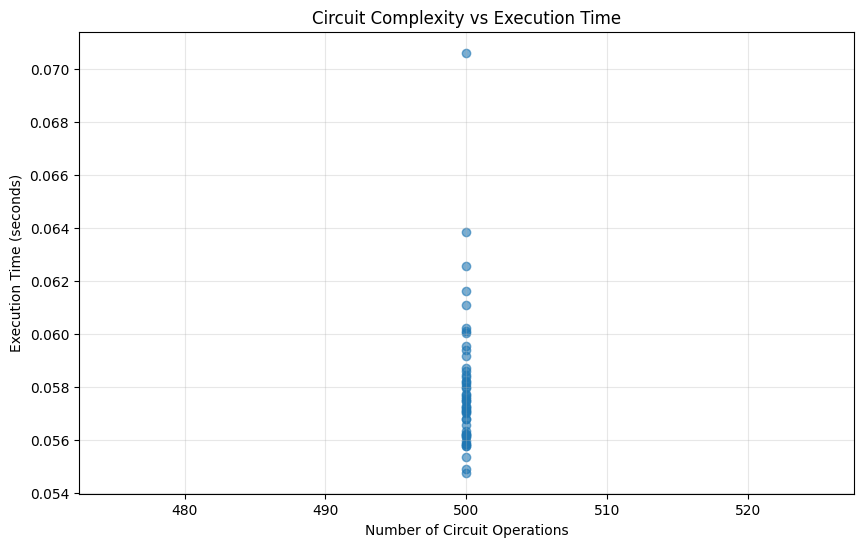

Correlation between circuit length and execution time: nan


/Users/ashutoshtiwari/Desktop/Research-Code/pqc-qec/.venv/lib/python3.13/site-packages/numpy/lib/_function_base_impl.py:3065: RuntimeWarning: invalid value encountered in divide
  c /= stddev[:, None]
/Users/ashutoshtiwari/Desktop/Research-Code/pqc-qec/.venv/lib/python3.13/site-packages/numpy/lib/_function_base_impl.py:3066: RuntimeWarning: invalid value encountered in divide
  c /= stddev[None, :]


In [33]:
# 5. CIRCUIT COMPLEXITY ANALYSIS
print("\n=== CIRCUIT COMPLEXITY ANALYSIS ===")
complexity_timer = DetailedTimer()

# Analyze how circuit complexity affects execution time
circuit_lengths = []
execution_times = []

for i, data in enumerate(good_data[:50]):  # Test subset
    circuit_length = len(data)  # Number of operations
    circuit_lengths.append(circuit_length)
    
    # Create and warm up circuit
    circuit = simple_circuit_generator(data, NUM_QUBITS, x_noise, z_noise)
    _ = circuit(input_states[0])  # Warm up
    
    # Time execution
    start_time = time.time()
    _ = circuit(input_states[0])
    execution_time = time.time() - start_time
    execution_times.append(execution_time)
    
    complexity_timer.add_time(f"length_{circuit_length}", execution_time)

# Plot complexity analysis
plt.figure(figsize=(10, 6))
plt.scatter(circuit_lengths, execution_times, alpha=0.6)
plt.xlabel('Number of Circuit Operations')
plt.ylabel('Execution Time (seconds)')
plt.title('Circuit Complexity vs Execution Time')

# Add trend line
z = np.polyfit(circuit_lengths, execution_times, 1)
p = np.poly1d(z)
plt.plot(circuit_lengths, p(circuit_lengths), "r--", alpha=0.8)

plt.grid(True, alpha=0.3)
plt.show()

# Calculate correlation
correlation = np.corrcoef(circuit_lengths, execution_times)[0, 1]
print(f"Correlation between circuit length and execution time: {correlation:.4f}")

In [34]:
# 6. SIMULATOR VS GENERATOR COMPARISON ANALYSIS
print("\n=== SIMULATOR VS GENERATOR COMPARISON ANALYSIS ===")
interface_timer = DetailedTimer()

# Compare simple_circuit_simulator vs simple_circuit_generator approaches
test_data = good_data[0]
test_input = input_states[0]

# Test simulator approach (creates circuit and executes immediately)
for _ in range(10):
    interface_timer.start_section("simulator_approach")
    output = simple_circuit_simulator(test_data, test_input, NUM_QUBITS, x_noise, z_noise)
    interface_timer.end_section()

# Test generator approach (create once, execute multiple times)
generated_circuit = simple_circuit_generator(test_data, NUM_QUBITS, x_noise, z_noise)
_ = generated_circuit(test_input)  # Warm up

for _ in range(10):
    interface_timer.start_section("generator_approach")
    output = generated_circuit(test_input)
    interface_timer.end_section()

print("Simulator vs Generator comparison:")
interface_summary = interface_timer.get_summary()
for section, stats in interface_summary.items():
    print(f"{section}: mean={stats['mean']:.6f}s, std={stats['std']:.6f}s")


=== SIMULATOR VS GENERATOR COMPARISON ANALYSIS ===
Simulator vs Generator comparison:
simulator_approach: mean=0.059562s, std=0.003404s
generator_approach: mean=0.060343s, std=0.001597s


In [35]:
# 7. MEMORY USAGE ANALYSIS
print("\n=== MEMORY USAGE ANALYSIS ===")

import psutil
import gc

def get_memory_usage():
    """Get current memory usage in MB"""
    process = psutil.Process()
    return process.memory_info().rss / 1024 / 1024

# Baseline memory
gc.collect()
baseline_memory = get_memory_usage()
print(f"Baseline memory usage: {baseline_memory:.2f} MB")

# Memory after creating circuits
memory_after_creation = get_memory_usage()
memory_for_circuits = memory_after_creation - baseline_memory
print(f"Memory after creating {len(individual_circuits)} circuits: {memory_after_creation:.2f} MB")
print(f"Memory used by circuits: {memory_for_circuits:.2f} MB")
print(f"Average memory per circuit: {memory_for_circuits/len(individual_circuits):.4f} MB")

# Memory during execution
test_circuit = individual_circuits[0]
memory_before_exec = get_memory_usage()
_ = test_circuit(input_states)
memory_after_exec = get_memory_usage()
memory_for_execution = memory_after_exec - memory_before_exec
print(f"Additional memory during batch execution: {memory_for_execution:.2f} MB")


=== MEMORY USAGE ANALYSIS ===
Baseline memory usage: 3475.83 MB
Memory after creating 100 circuits: 3475.83 MB
Memory used by circuits: 0.00 MB
Average memory per circuit: 0.0000 MB
Additional memory during batch execution: 0.00 MB


In [36]:
# 8. COMPREHENSIVE SUMMARY AND RECOMMENDATIONS
print("\n=== COMPREHENSIVE ANALYSIS SUMMARY ===")

# Combine all timing data
all_timers = [creation_timer, compilation_timer, batch_timer, interface_timer]
all_summaries = [timer.get_summary() for timer in all_timers]

# Create comprehensive DataFrame
all_data = {}
for summary in all_summaries:
    all_data.update(summary)

if all_data:
    df_summary = pd.DataFrame(all_data).T
    df_summary = df_summary.sort_values('mean', ascending=False)
    
    print("Complete Performance Summary (sorted by mean time):")
    print(df_summary[['mean', 'std', 'total', 'count']].round(6))
    
    # Generate recommendations
    print("\n=== PERFORMANCE RECOMMENDATIONS ===")
    
    # Check for major bottlenecks
    fastest_mean = df_summary['mean'].min()
    slowest_mean = df_summary['mean'].max()
    
    if slowest_mean > fastest_mean * 10:
        slowest_section = df_summary.index[0]
        print(f"⚠️  MAJOR BOTTLENECK: '{slowest_section}' is {slowest_mean/fastest_mean:.1f}x slower than fastest operation")
    
    # Batch size recommendations
    batch_sections = [idx for idx in df_summary.index if 'batch_size_' in idx]
    if batch_sections:
        batch_data = [(int(idx.split('_')[-1]), df_summary.loc[idx, 'mean']) for idx in batch_sections]
        batch_data.sort()
        
        print(f"\n📊 BATCH SIZE ANALYSIS:")
        optimal_batch = min(batch_data, key=lambda x: x[1]/x[0])  # Best time per state
        print(f"   Most efficient batch size: {optimal_batch[0]} ({optimal_batch[1]/optimal_batch[0]:.8f}s per state)")
        
        for batch_size, time in batch_data:
            time_per_state = time / batch_size
            print(f"   Batch {batch_size:3d}: {time_per_state:.8f}s per state")
    
    # Interface recommendations
    interface_sections = [idx for idx in df_summary.index if 'interface' in idx]
    if interface_sections:
        print(f"\n🔧 INTERFACE ANALYSIS:")
        for section in interface_sections:
            mean_time = df_summary.loc[section, 'mean']
            print(f"   {section}: {mean_time:.6f}s average")
    
    print(f"\n💡 OPTIMIZATION SUGGESTIONS:")
    print("   1. Pre-compile circuits when possible (avoid repeated creation)")
    print("   2. Use optimal batch sizes for your use case")
    print("   3. Consider caching compiled circuits for repeated use")
    print("   4. Monitor memory usage for large-scale experiments")
    
else:
    print("No timing data available for summary.")


=== COMPREHENSIVE ANALYSIS SUMMARY ===
Complete Performance Summary (sorted by mean time):
                                       mean       std     total  count
batch_size_100                     0.118899  0.001857  0.594497    5.0
batch_execution_after_compilation  0.113328  0.003379  0.566641    5.0
batch_size_50                      0.086202  0.000206  0.431009    5.0
batch_size_20                      0.067063  0.000853  0.335313    5.0
batch_size_10                      0.060468  0.000681  0.302339    5.0
generator_approach                 0.060343  0.001597  0.603431   10.0
simulator_approach                 0.059562  0.003404  0.595623   10.0
batch_size_5                       0.057234  0.000597  0.286170    5.0
first_execution_single_state       0.057232  0.001968  0.286160    5.0
batch_size_1                       0.056834  0.002892  0.284169    5.0
second_execution_single_state      0.056107  0.001423  0.280536    5.0
batch_size_2                       0.055096  0.000185  0

## Additional Profiling Tools

You can also use these cells to do targeted analysis of specific bottlenecks:

In [37]:
# TARGETED BOTTLENECK ANALYSIS
# Use this cell to investigate specific performance issues

# Example: Analyze a specific function call
import time

def analyze_function_performance(func, *args, **kwargs):
    """Analyze performance of a specific function call"""
    with profile_execution(f"Analysis of {func.__name__}"):
        result = func(*args, **kwargs)
    return result

# Example usage:
# result = analyze_function_performance(simple_circuit_generator, good_data[0], NUM_QUBITS, x_noise, z_noise)
# result = analyze_function_performance(simple_circuit_simulator, good_data[0], input_states[0], NUM_QUBITS, x_noise, z_noise)

# Quick timing function for any code block
def quick_time(func, *args, iterations=10, **kwargs):
    """Quick timing analysis with statistics"""
    times = []
    for _ in range(iterations):
        start = time.time()
        result = func(*args, **kwargs)
        times.append(time.time() - start)
    
    times = np.array(times)
    print(f"Function: {func.__name__}")
    print(f"Mean: {times.mean():.6f}s")
    print(f"Std:  {times.std():.6f}s")
    print(f"Min:  {times.min():.6f}s")
    print(f"Max:  {times.max():.6f}s")
    return result

# Example: Quick timing of different approaches
print("=== QUICK COMPARISON ===")
print("Simulator approach:")
quick_time(simple_circuit_simulator, good_data[0], input_states[0], NUM_QUBITS, x_noise, z_noise, iterations=5)

print("\nGenerator approach (with circuit creation):")
def generator_with_creation(data, state, num_qubits, x_noise, z_noise):
    circuit = simple_circuit_generator(data, num_qubits, x_noise, z_noise)
    return circuit(state)

quick_time(generator_with_creation, good_data[0], input_states[0], NUM_QUBITS, x_noise, z_noise, iterations=5)

print("\nGenerator approach (pre-created circuit):")
pre_created_circuit = simple_circuit_generator(good_data[0], NUM_QUBITS, x_noise, z_noise)
quick_time(pre_created_circuit, input_states[0], iterations=5)

=== QUICK COMPARISON ===
Simulator approach:
Function: simple_circuit_simulator
Mean: 0.059462s
Std:  0.002525s
Min:  0.056640s
Max:  0.063833s

Generator approach (with circuit creation):
Function: generator_with_creation
Mean: 0.060324s
Std:  0.001092s
Min:  0.058329s
Max:  0.061337s

Generator approach (pre-created circuit):
Function: circuit
Mean: 0.059232s
Std:  0.002922s
Min:  0.055723s
Max:  0.062805s


array([-0.02774539-0.07022579j,  0.00320734-0.09782666j,
        0.03223965+0.0371112j ,  0.01420459-0.03403538j,
       -0.23629612+0.03973683j, -0.23755529-0.05488342j,
        0.23564851-0.02979988j,  0.23256159+0.09274818j,
       -0.22783231+0.02628947j, -0.2363592 +0.04174997j,
       -0.24442689-0.04849222j, -0.23560307-0.08132639j,
        0.00063162+0.02697479j,  0.01524994-0.01646926j,
       -0.01207428+0.09302868j, -0.00736876-0.00694585j,
       -0.01548891-0.03315584j, -0.00731737-0.00882555j,
        0.00362111+0.03519422j, -0.00046034+0.0025593j ,
        0.24829252+0.05575625j, -0.22336372-0.00531896j,
       -0.24750256-0.00173693j,  0.2475011 -0.04419521j,
       -0.25161181-0.01045269j,  0.2338448 +0.01366068j,
       -0.24997608+0.00491375j,  0.24871832-0.01832099j,
       -0.00914503+0.00569575j, -0.01087753-0.11354065j,
        0.00052841-0.02637984j,  0.01076633+0.04005066j])